# Create Monthly Price Index

In [ ]:
import os
import sys
import warnings
from datetime import datetime
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.simplefilter(action="ignore", category=FutureWarning)

CURRENT_DIR = os.path.abspath("")

# NOTE: this has to be before any import from this project (src.*)
# add parent dir to python path
sys.path.append(os.path.join(CURRENT_DIR, *[".."] * 2))

DATA_DIR = os.path.join(CURRENT_DIR, *[".."] * 2, "data", "autoencoder")

# create dataset folder autoencoder
os.makedirs(DATA_DIR, exist_ok=True)

PRICES_DATASET_PATH = os.path.join(DATA_DIR, "prices_index.jsonl")

In [53]:
# load prices_nbp.tsv from DATA_DIR
df = pd.read_csv(os.path.join(DATA_DIR, "prices_nbp.tsv"), sep="\t")

In [54]:
df

,Kwartał,Białystok,Bydgoszcz,Gdańsk,Gdynia*,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
0,III 2006,2 727,3 243,5 004,4 937,3 986,2 919,6 021,3 456,3 210,4 000,3 343,4 770,2 862,3 215,5 873,4 750,2 754
1,IV 2006,2 727,3 947,6 199,5 284,4 062,3 493,7 929,3 314,4 237,4 800,NaN,4 827,3 401,3 679,6 095,5 759,2 869
2,I 2007,4 181,4 501,6 437,6 466,4 518,3 382,8 247,3 604,4 927,5 149,NaN,7 275,3 420,4 749,7 509,6 309,2 872
3,II 2007,4 725,5 700,7 999,8 934,5 181,3 902,8 129,4 143,5 453,4 776,NaN,7 360,4 080,5 050,8 000,6 294,4 153
4,III 2007,4 199,4 994,8 053,8 114,6 236,4 651,8 420,4 645,5 201,4 900,4 784,6 838,4 069,5 035,8 740,6 444,4 208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,IV 2023,9 846,9 701,13 063,11 395,11 267,8 719,14 555,10 703,10 197,8 951,10 301,12 435,9 891,12 399,15 559,13 353,7 853
70,I 2024,9 941,9 941,13 827,11 307,11 342,9 034,15 585,10 880,10 708,9 788,10 063,12 811,10 264,12 206,16 190,13 531,8 165
71,II 2024,10 628,10 016,13 848,11 598,11 922,9 722,16 752,11 257,11 247,9 876,11 295,12 789,10 498,12 459,16 512,13 992,8 570
72,III 2024,10 787,10 286,13 773,12 496,12 144,10 060,16 570,11 042,11 465,10 042,11 349,12 953,10 615,12 998,16 821,15 275,9 130


In [55]:
# Step 1. Clean the data: remove non-breaking spaces and convert to numeric.
def clean_price(value: str) -> float:
    try:
        # Remove non-breaking spaces and convert to float
        return float(value.replace("\xa0", ""))
    except Exception:
        return np.nan


for col in df.columns:
    if col != "Kwartał":
        # Apply cleaning if the value is not missing.
        df[col] = df[col].apply(lambda x: clean_price(str(x)) if pd.notnull(x) else np.nan)

# Step 2. Parse the "Kwartał" column into quarterly periods.
quarter_mapping: dict = {"I": 1, "II": 2, "III": 3, "IV": 4}


def parse_quarter(q_str: str) -> pd.Period:
    parts = q_str.split()
    # parts[0] is the Roman numeral for quarter, parts[1] is the year
    q_num = quarter_mapping.get(parts[0])
    year = int(parts[1])
    return pd.Period(year=year, quarter=q_num, freq="Q")


In [56]:
def calculate_hpi(df: pd.DataFrame, city_columns: List[str], smoothing_window: int = 4) -> pd.DataFrame:
    # Step 3. Interpolate missing values for each city column.
    df[city_columns] = df[city_columns].interpolate(method="linear", limit_direction="both")

    # Step 4. Smooth the data using a rolling average over 4 quarters.
    df_smoothed = df.copy()
    for city in city_columns:
        df_smoothed[city] = df_smoothed[city].rolling(window=smoothing_window, min_periods=1, center=True).mean()

    # Step 5. Compute the Housing Price Index (HPI) using the latest quarter as the reference.
    latest_period = df_smoothed.index.max()
    hpi_df = pd.DataFrame(index=df_smoothed.index)
    for city in city_columns:
        ref_price = df_smoothed.loc[latest_period, city]
        hpi_df[city] = (df_smoothed[city] / ref_price) * 100

    # Calculate the average HPI across all cities
    hpi_df["Average_HPI"] = hpi_df[city_columns].mean(axis=1)

    return hpi_df

In [57]:
# Create a new column with the parsed quarter periods and sort by it.
df["Period"] = df["Kwartał"].apply(parse_quarter)
df = df.sort_values(by="Period")
df.set_index("Period", inplace=True)

city_columns: list = [col for col in df.columns if col != "Kwartał"]

In [ ]:
# Calculate HPI
hpi_df = calculate_hpi(df, city_columns, 8)


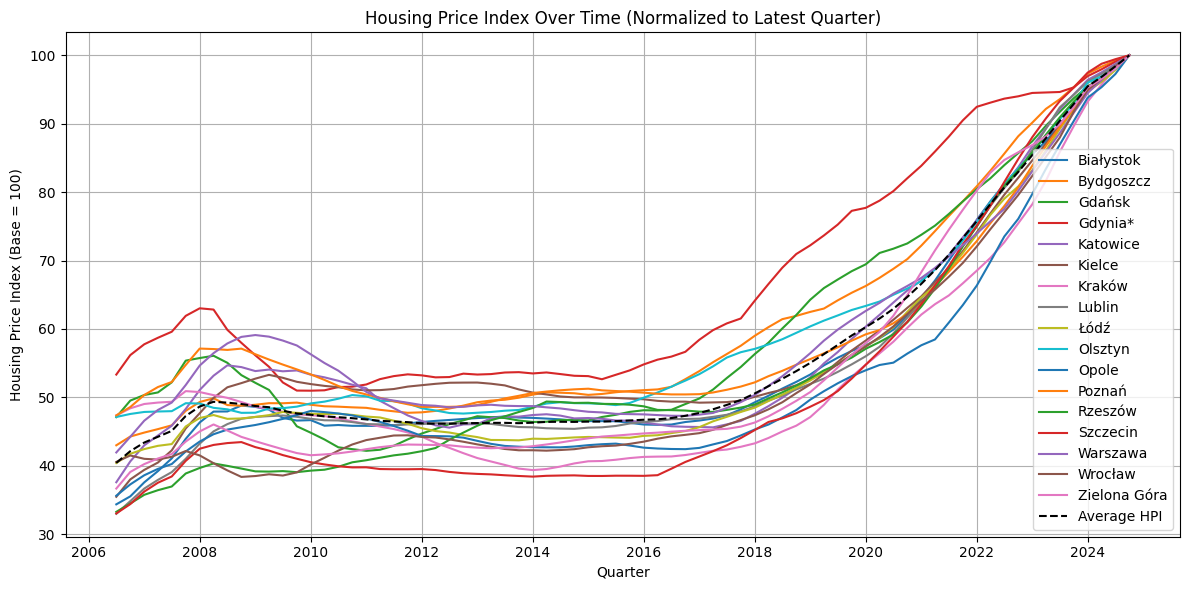

In [59]:
# Step 6. Plot the HPI for each city over time.
plt.figure(figsize=(12, 6))
for city in city_columns:
    # Convert Period index to a timestamp for better plotting on the x-axis.
    plt.plot(hpi_df.index.to_timestamp(), hpi_df[city], label=city)

# Plot the average HPI
plt.plot(hpi_df.index.to_timestamp(), hpi_df["Average_HPI"], label="Average HPI", linestyle="--", color="black")

plt.xlabel("Quarter")
plt.ylabel("Housing Price Index (Base = 100)")
plt.title("Housing Price Index Over Time (Normalized to Latest Quarter)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
hpi_df

,Białystok,Bydgoszcz,Gdańsk,Gdynia*,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra,Average_HPI
Period,,,,,,,,,,,,,,,,,,
2006Q3,34.371829,43.001899,47.119428,53.336192,37.598939,35.474513,47.358920,32.990782,40.409375,47.139649,35.633832,47.374760,33.275469,33.041836,41.953718,40.577552,36.679581,40.431663
2006Q4,35.537981,44.280260,49.535403,56.181927,40.648464,38.016991,48.406482,34.837466,41.758999,47.580207,37.286658,48.594710,34.490629,34.406423,44.238826,41.512985,39.106327,42.142396
2007Q1,37.585610,44.860509,50.348447,57.764048,42.995034,39.408067,49.037184,36.677636,42.448696,47.873912,38.622530,50.354255,35.764943,36.234581,46.597937,41.025839,40.254352,43.403152
2007Q2,39.230115,45.365402,50.727560,58.715699,44.429029,40.481617,49.245852,37.945292,42.923202,47.939845,39.554440,51.517230,36.441683,37.531359,48.166102,40.911636,41.074370,44.247084
2007Q3,41.089415,45.919629,52.205547,59.595976,45.865748,42.260671,49.363311,39.081249,43.181612,47.989296,40.265989,52.250653,36.981877,38.445551,49.245270,41.327233,41.719834,45.105227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023Q4,92.341976,95.343006,93.716920,95.304017,94.273826,92.294343,89.638538,94.219284,92.051637,92.923640,90.385851,92.244123,93.236833,95.270661,91.601317,91.752461,92.445711,92.884950
2024Q1,95.102972,97.319892,95.427914,96.951712,96.398790,95.374016,93.241289,96.166870,94.744537,95.986144,93.806203,94.807193,95.306425,97.466786,94.484041,94.967133,95.287741,95.461156
2024Q2,96.682907,98.329617,96.660030,97.947526,97.506822,96.586940,95.722656,97.263056,96.115436,96.919766,95.335973,96.417456,96.557955,98.754233,96.375829,96.547005,96.557747,96.840056


In [70]:
# create a column that will convert the Period index to a timestamp The survey is carried out according to the schedule: I quarter - December, January, February, II quarter - March, April, May, III quarter - June, July, August, IV quarter - September, October, November.


def get_period_start(period: str) -> datetime:
    year, quarter = period.split("Q")

    if quarter == "1":
        date = datetime(year=int(year) - 1, month=12, day=1)
    elif quarter == "2":
        date = datetime(year=int(year), month=3, day=1)
    elif quarter == "3":
        date = datetime(year=int(year), month=6, day=1)
    elif quarter == "4":
        date = datetime(year=int(year), month=9, day=1)
    else:
        raise ValueError(f"Invalid quarter: {quarter}")

    return date.isoformat()


def get_period_end(period: str) -> datetime:
    year, quarter = period.split("Q")

    if quarter == "1":
        date = datetime(year=int(year), month=2, day=28)
    elif quarter == "2":
        date = datetime(year=int(year), month=5, day=31)
    elif quarter == "3":
        date = datetime(year=int(year), month=8, day=31)
    elif quarter == "4":
        date = datetime(year=int(year), month=11, day=30)
    else:
        raise ValueError(f"Invalid quarter: {quarter}")

    return date.isoformat()


hpi_df["period_start"] = hpi_df.index.map(lambda x: get_period_start(str(x)))
hpi_df["period_end"] = hpi_df.index.map(lambda x: get_period_end(str(x)))

In [71]:
hpi_df

,Białystok,Bydgoszcz,Gdańsk,Gdynia*,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra,Average_HPI,period_start,period_end
Period,,,,,,,,,,,,,,,,,,,,
2006Q3,34.371829,43.001899,47.119428,53.336192,37.598939,35.474513,47.358920,32.990782,40.409375,47.139649,35.633832,47.374760,33.275469,33.041836,41.953718,40.577552,36.679581,40.431663,2006-06-01T00:00:00,2006-08-31T00:00:00
2006Q4,35.537981,44.280260,49.535403,56.181927,40.648464,38.016991,48.406482,34.837466,41.758999,47.580207,37.286658,48.594710,34.490629,34.406423,44.238826,41.512985,39.106327,42.142396,2006-09-01T00:00:00,2006-11-30T00:00:00
2007Q1,37.585610,44.860509,50.348447,57.764048,42.995034,39.408067,49.037184,36.677636,42.448696,47.873912,38.622530,50.354255,35.764943,36.234581,46.597937,41.025839,40.254352,43.403152,2006-12-01T00:00:00,2007-02-28T00:00:00
2007Q2,39.230115,45.365402,50.727560,58.715699,44.429029,40.481617,49.245852,37.945292,42.923202,47.939845,39.554440,51.517230,36.441683,37.531359,48.166102,40.911636,41.074370,44.247084,2007-03-01T00:00:00,2007-05-31T00:00:00
2007Q3,41.089415,45.919629,52.205547,59.595976,45.865748,42.260671,49.363311,39.081249,43.181612,47.989296,40.265989,52.250653,36.981877,38.445551,49.245270,41.327233,41.719834,45.105227,2007-06-01T00:00:00,2007-08-31T00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023Q4,92.341976,95.343006,93.716920,95.304017,94.273826,92.294343,89.638538,94.219284,92.051637,92.923640,90.385851,92.244123,93.236833,95.270661,91.601317,91.752461,92.445711,92.884950,2023-09-01T00:00:00,2023-11-30T00:00:00
2024Q1,95.102972,97.319892,95.427914,96.951712,96.398790,95.374016,93.241289,96.166870,94.744537,95.986144,93.806203,94.807193,95.306425,97.466786,94.484041,94.967133,95.287741,95.461156,2023-12-01T00:00:00,2024-02-28T00:00:00
2024Q2,96.682907,98.329617,96.660030,97.947526,97.506822,96.586940,95.722656,97.263056,96.115436,96.919766,95.335973,96.417456,96.557955,98.754233,96.375829,96.547005,96.557747,96.840056,2024-03-01T00:00:00,2024-05-31T00:00:00


In [72]:
# save to jsonl
hpi_df.to_json(os.path.join(DATA_DIR, "housing_price_index.jsonl"), orient="records", lines=True)